In [3]:
# 1. Import Libraries
# 2. Load Master Dataset
# 3. Dataset Overview
# 4. Top Skills Analysis
# 5. Role Distribution Analysis
# 6. Role-wise Skill Comparison
# 7. Top Hiring Companies
# 8. Top Hiring Locations
# 9. Experience Analysis
# 10. Salary Analysis
# 11. Correlation Analysis
# 12. Business Insights
# 13. Recommendations

(17017, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17017 entries, 0 to 17016
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           17017 non-null  object 
 1   company             17017 non-null  object 
 2   location            17017 non-null  object 
 3   description         16975 non-null  object 
 4   salary              15969 non-null  object 
 5   rating              12475 non-null  float64
 6   industry            2252 non-null   object 
 7   experience          13619 non-null  object 
 8   date_posted         14742 non-null  object 
 9   tagsAndSkills       13623 non-null  object 
 10  source              17017 non-null  object 
 11  text_data           17017 non-null  object 
 12  python              17017 non-null  int64  
 13  sql                 17017 non-null  int64  
 14  excel               17017 non-null  int64  
 15  power bi            17017 non-null  int64

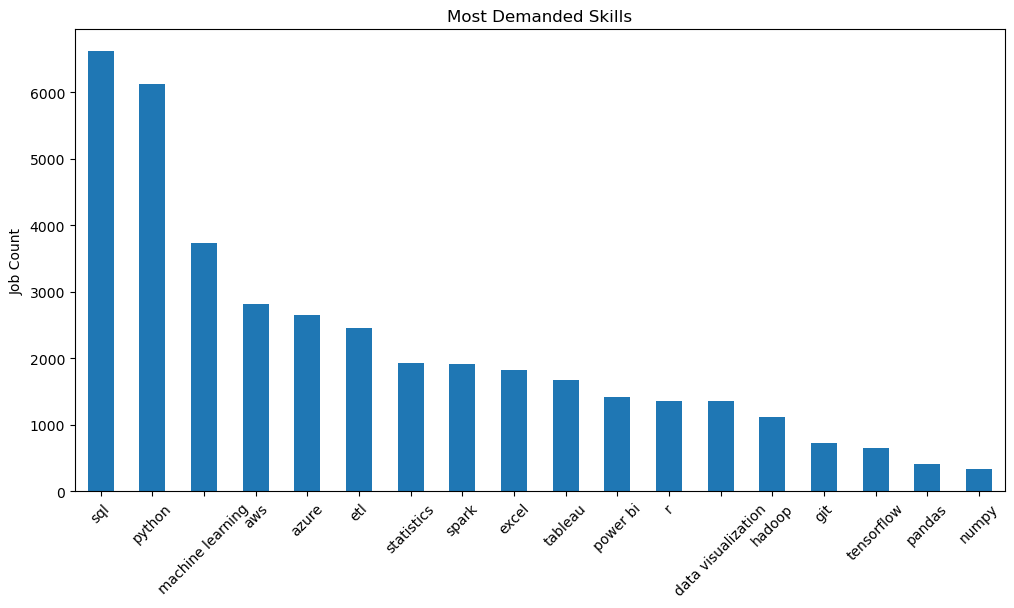

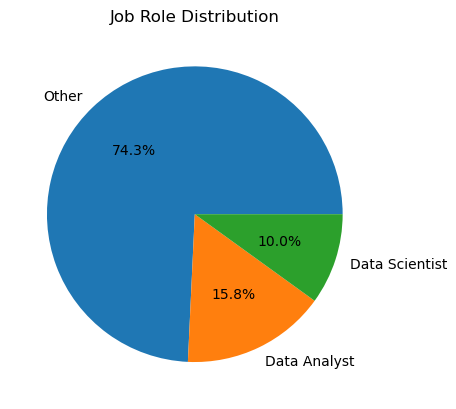

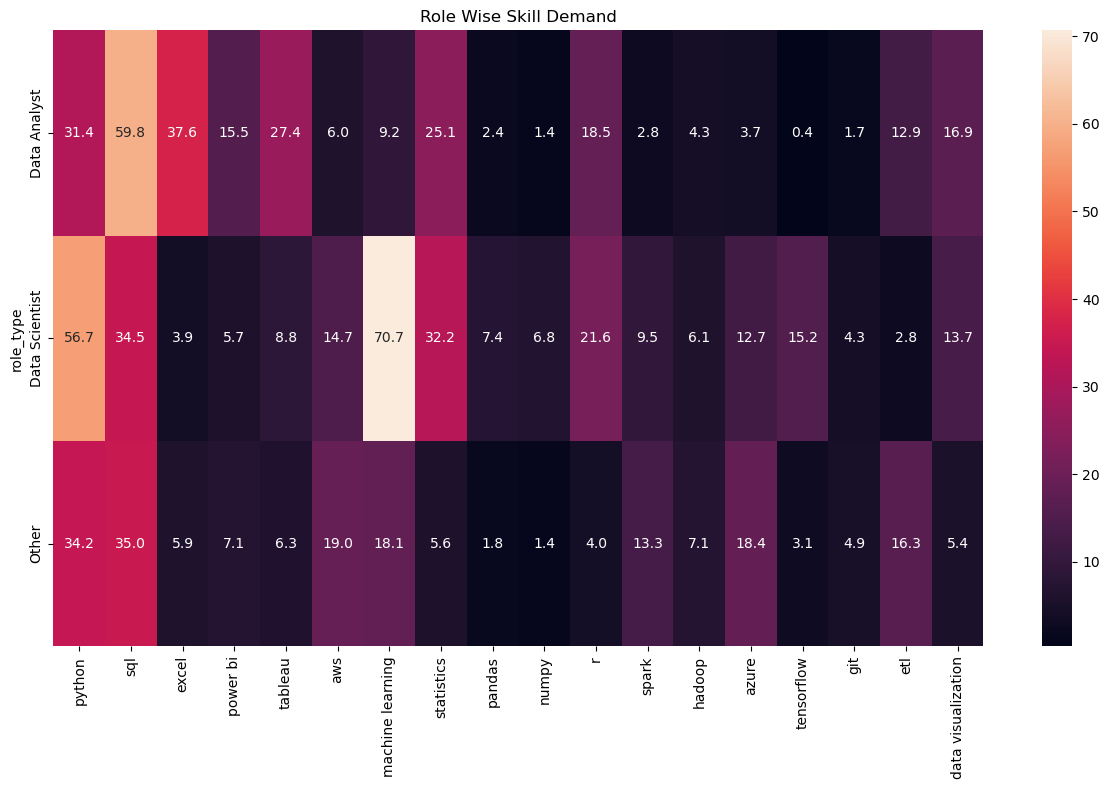

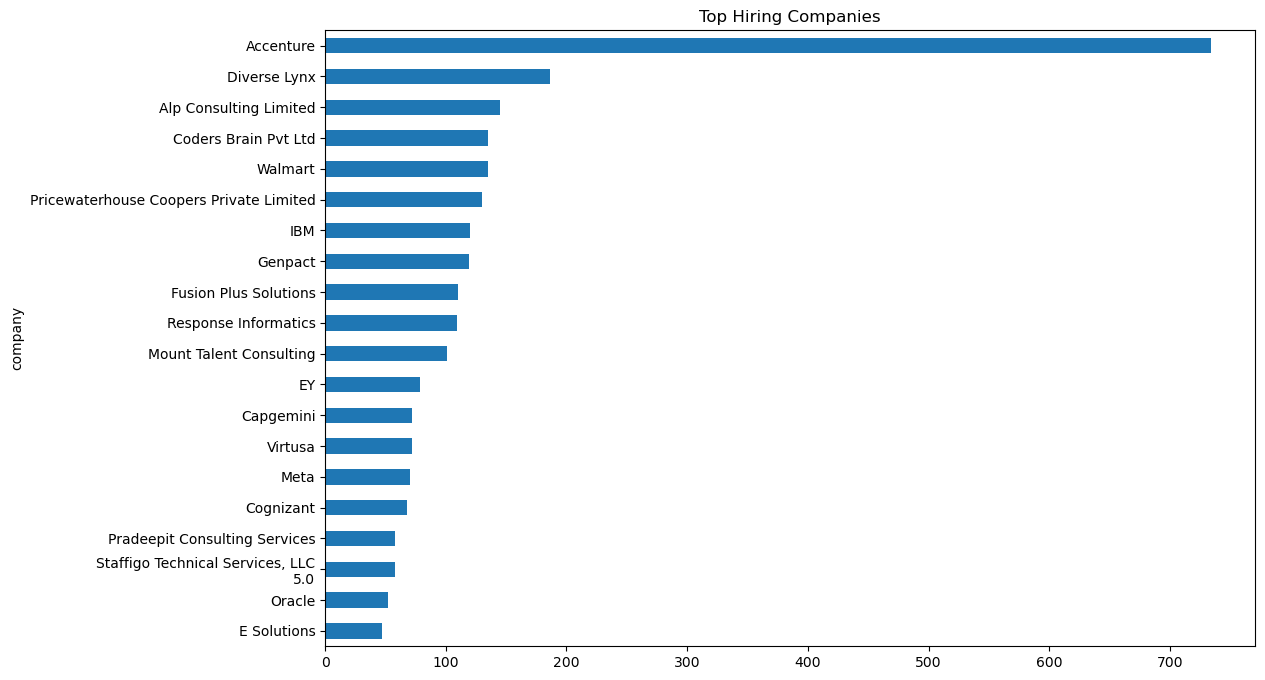

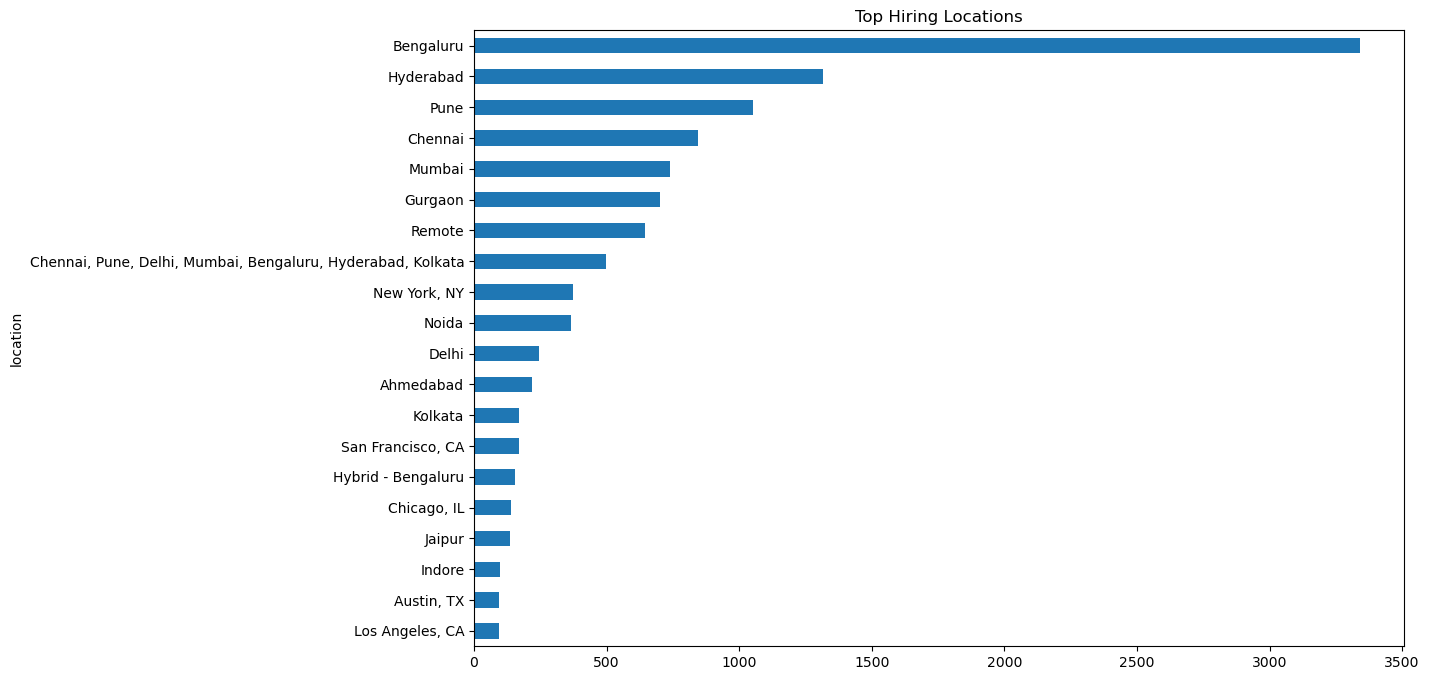

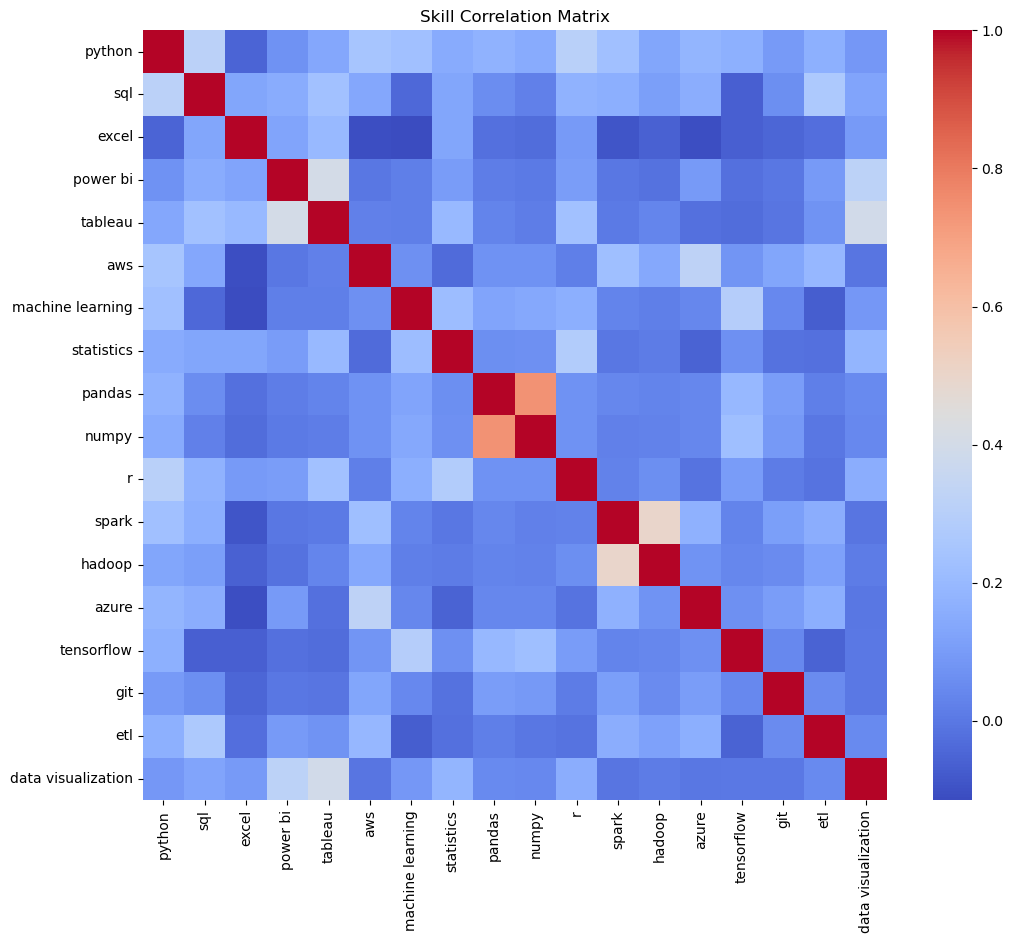

KeyError: 'Column not found: experience_clean'

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# 2. Load Dataset
# --------------------------------------------
master_df = pd.read_csv(
    "master_jobs_dataset_v1.csv"
)

master_df.head()

# 3. Dataset Overview
# --------------------------------------------
print(master_df.shape)

master_df.info()

master_df.describe(include='all')

# Top Skills Analysis
# --------------------------------------------
skills = [
    'python',
    'sql',
    'excel',
    'power bi',
    'tableau',
    'aws',
    'machine learning',
    'statistics',
    'pandas',
    'numpy',
    'r',
    'spark',
    'hadoop',
    'azure',
    'tensorflow',
    'git',
    'etl',
    'data visualization'
]

skill_counts = (
    master_df[skills]
    .sum()
    .sort_values(ascending=False)
)

skill_counts

# Visualization
# ------------------------------------------------
plt.figure(figsize=(12,6))

skill_counts.plot(kind='bar')

plt.title("Most Demanded Skills")
plt.ylabel("Job Count")
plt.xticks(rotation=45)

plt.show()

# 5. Role Distribution
# -------------------------------------------------
master_df['role_type'].value_counts()
master_df['role_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title("Job Role Distribution")

plt.show()

# 6. Data Analyst vs Data Scientist
# ------------------------------------------------
role_skill = (
    master_df
    .groupby('role_type')[skills]
    .mean()*100
)

role_skill.round(2)
plt.figure(figsize=(15,8))

sns.heatmap(
    role_skill,
    annot=True,
    fmt='.1f'
)

plt.title("Role Wise Skill Demand")

plt.show()

# 7. Top Hiring Companies
# -------------------------------------------------
top_companies = (
    master_df['company']
    .value_counts()
    .head(20)
)

top_companies

plt.figure(figsize=(12,8))

top_companies.sort_values().plot(
    kind='barh'
)

plt.title("Top Hiring Companies")

plt.show()

# 8. Top Hiring Locations
# -----------------------------------------------------
top_locations = (
    master_df['location']
    .value_counts()
    .head(20)
)

top_locations
plt.figure(figsize=(12,8))

top_locations.sort_values().plot(
    kind='barh'
)

plt.title("Top Hiring Locations")

plt.show()

# 9. Experience Analysis
# ---------------------------------------------------------
master_df['experience'].dropna().head(20)

# 10. Salary Analysis
# ---------------------------------------------------------
master_df['salary'].dropna().head(20)

# 11. Correlation Analysis
# ---------------------------------------------------------
skill_corr = master_df[skills].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    skill_corr,
    cmap='coolwarm'
)

plt.title("Skill Correlation Matrix")

plt.show()

master_df['salary'].dropna().sample(20)
master_df['experience'].dropna().sample(20)
master_df['salary'].dropna().sample(20)

# ==================================================
# SALARY CLEANING
# ==================================================

import re

def extract_salary(salary):

    if pd.isna(salary):
        return np.nan

    salary = str(salary)

    # Indian Salary Format
    indian = re.findall(r'(\d+\.?\d*)', salary)

    if 'Lacs' in salary and len(indian) >= 2:

        low = float(indian[0])
        high = float(indian[1])

        return (low + high) / 2

    # Dollar Salary Format

    dollar = re.findall(r'(\d+)K', salary)

    if len(dollar) >= 2:

        low = float(dollar[0])
        high = float(dollar[1])

        return (low + high) / 2

    return np.nan

master_df['salary_clean'] = (
    master_df['salary']
    .apply(extract_salary)
)

master_df[['salary','salary_clean']].head(20)

master_df['salary_clean'].describe()

skill_counts.head(15)

top_locations = (
    master_df['location']
    .value_counts()
    .head(20)
)

top_locations

top_companies = (
    master_df['company']
    .value_counts()
    .head(20)
)

top_companies

master_df.groupby(
    'role_type'
)['experience_clean'].mean()

powerbi_df = master_df[
    [
        'job_title',
        'company',
        'location',
        'role_type',
        'experience_clean',
        'source',
        'python',
        'sql',
        'excel',
        'power bi',
        'tableau',
        'aws',
        'machine learning',
        'statistics',
        'pandas',
        'numpy',
        'r',
        'spark',
        'hadoop',
        'azure',
        'tensorflow',
        'git',
        'etl',
        'data visualization'
    ]
]

powerbi_df.to_csv(
    "job_market_dashboard.csv",
    index=False
)